# **Project Name**    - Aerial Object Classification and Detection




##### **Project Type**    - Deep Learning/Computer Vision
##### **Contribution**    - Individual
##### **Member Name-**    - Avinash Singh


# **Project Summary -**

The Aerial Object Classification & Detection project focuses on building an intelligent deep learning system capable of distinguishing between two visually similar aerial objects: birds and drones. This distinction is critical in real-world applications such as airspace monitoring, wildlife conservation, and defense surveillance. The project integrates both image classification and object detection techniques to provide a robust and practical solution for identifying and localizing aerial objects in images or video frames.

At its core, the project leverages computer vision and deep learning methodologies to process aerial imagery. The primary objective is to classify images into two categories—Bird or Drone—using a trained convolutional neural network (CNN). Additionally, the system optionally incorporates YOLOv8, a state-of-the-art object detection model, to identify and draw bounding boxes around detected objects, enabling real-time localization in complex scenes.

The workflow begins with a thorough understanding of the dataset, including analyzing class distribution, identifying imbalance, and visualizing sample images. The classification dataset consists of thousands of labeled RGB images split into training, validation, and testing sets. Preprocessing steps such as resizing images to a fixed dimension and normalizing pixel values are applied to ensure consistency. To improve model generalization and performance, data augmentation techniques—including rotation, flipping, zooming, and brightness adjustments—are used.

For model development, both custom CNN architectures and transfer learning approaches are explored. Pre-trained models like ResNet50, MobileNet, and EfficientNetB0 are fine-tuned to enhance performance while reducing training time. The training phase includes the use of techniques such as EarlyStopping and ModelCheckpoint to prevent overfitting and retain the best-performing model. Model performance is evaluated using metrics such as accuracy, precision, recall, F1-score, and confusion matrices.

An additional feature of the project is the implementation of object detection using YOLOv8. This involves preparing the dataset in YOLO format, creating configuration files, and training the model to detect and localize objects with bounding boxes. The detection model enhances the system’s capability by enabling real-time identification of drones and birds within larger scenes.

The final stage of the project involves deploying the trained models through a Streamlit web application, providing an interactive user interface. Users can upload images and receive classification results along with confidence scores. If object detection is enabled, the application also displays annotated images with bounding boxes. This deployment makes the solution accessible and user-friendly, bridging the gap between machine learning models and practical usage.

The project has significant real-world applications, including preventing bird strikes at airports, detecting unauthorized drones in restricted zones, monitoring wildlife, and supporting environmental research. By combining classification and detection techniques, the system provides a comprehensive approach to aerial object analysis.

Overall, this project demonstrates the effective use of deep learning, computer vision, and deployment tools to solve a critical real-world problem. It showcases end-to-end development—from data preprocessing and model training to evaluation and deployment—making it a strong example of applied artificial intelligence in aerial surveillance systems.

# **GitHub Link -**

https://github.com/avinashsingh03/Aerial-Object-Classifiction-and-Detection

# **Problem Statement**


The objective of this project is to develop a deep learning-based system that can accurately classify aerial images into two categories—Bird and Drone—and optionally detect their location within images. This is important because birds and drones often appear similar in aerial views, making manual identification difficult and error-prone. The system aims to improve accuracy and efficiency in distinguishing between these objects for real-world applications such as surveillance and monitoring.

#### **Define Your Business Objective?**

The business objective is to build a reliable and automated solution that can detect and differentiate between birds and drones in aerial environments to enhance safety, security, and monitoring systems. This solution can be used to:

* Prevent bird strikes at airports
* Detect unauthorized drones in restricted areas
* Support wildlife monitoring and environmental research
* Improve airspace safety and surveillance systems

# ***Let's Begin !***

### Import Libraries

In [1]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os
from pathlib import Path
from PIL import Image
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2,EfficientNetB0,ResNet50
from tensorflow.keras.optimizers import Adam


### Dataset Loading

In [2]:
# Load Dataset from drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Dataset First View

In [3]:
# Dataset First Look
classification_dataset_path = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset"
train_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/train"
val_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/test"

In [4]:
def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count} images")
            total += count
    print(f"Total images in {folder}: {total}\n")

print("TRAIN DATASET")
count_images(train_dir)

print("VALIDATION DATASET")
count_images(val_dir)

print("TEST DATASET")
count_images(test_dir)

TRAIN DATASET
bird: 1414 images
drone: 1248 images
Total images in /content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/train: 2662

VALIDATION DATASET
bird: 217 images
drone: 225 images
Total images in /content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/valid: 442

TEST DATASET
bird: 121 images
drone: 94 images
Total images in /content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/test: 215



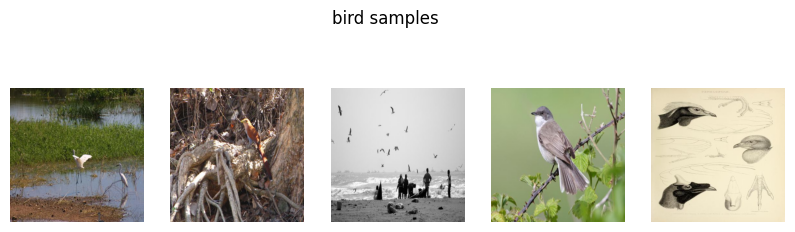

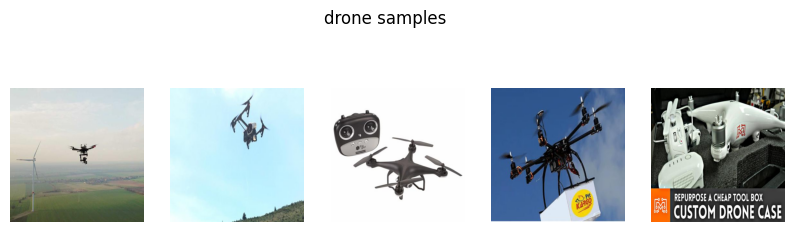

In [5]:
def show_sample_images(folder, num_images=5):
    classes = os.listdir(folder)
    for cls in classes:
        cls_path = os.path.join(folder, cls)
        images = os.listdir(cls_path)[:num_images]

        plt.figure(figsize=(10,3))
        for i, img_name in enumerate(images):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, num_images, i+1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(f"{cls} samples")
        plt.show()

show_sample_images(train_dir)

### Data Augmentation

Data augmentation is a technique used to artificially increase the size and diversity of the training dataset by applying various transformations to the images. Instead of collecting new data, existing images are modified using operations such as rotation, flipping, zooming, shifting, and brightness adjustments.

In this project, data augmentation is applied only to the training dataset to help the model generalize better and reduce overfitting. It allows the model to learn different variations of the same object, making it more robust to real-world scenarios where objects may appear in different orientations or lighting conditions.

In [6]:
img=cv2.imread("/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/test/bird/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg")

array([[[191, 172, 134],
        [191, 172, 134],
        [191, 172, 134],
        ...,
        [188, 180, 151],
        [188, 180, 150],
        [188, 180, 150]],

       [[191, 172, 134],
        [191, 172, 134],
        [191, 172, 134],
        ...,
        [188, 180, 151],
        [188, 180, 150],
        [188, 180, 150]],

       [[190, 174, 132],
        [190, 174, 132],
        [190, 174, 132],
        ...,
        [189, 178, 150],
        [189, 179, 149],
        [189, 179, 149]],

       ...,

       [[156, 152, 147],
        [162, 158, 153],
        [174, 170, 165],
        ...,
        [128, 120, 113],
        [129, 121, 114],
        [129, 121, 114]],

       [[137, 133, 128],
        [144, 140, 135],
        [153, 149, 144],
        ...,
        [130, 122, 115],
        [130, 122, 115],
        [130, 122, 115]],

       [[127, 123, 118],
        [129, 125, 120],
        [129, 125, 120],
        ...,
        [131, 123, 116],
        [132, 124, 117],
        [132, 124, 117]]], dtype=uint8)
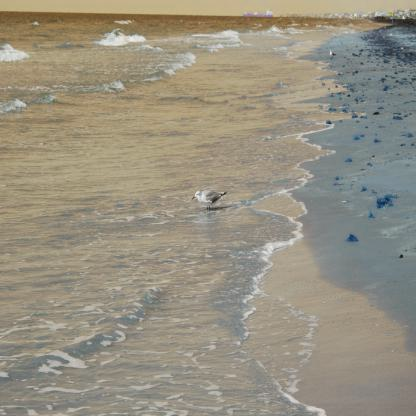

In [7]:
img

array([[[188, 180, 150],
        [188, 180, 150],
        [188, 180, 151],
        ...,
        [191, 172, 134],
        [191, 172, 134],
        [191, 172, 134]],

       [[188, 180, 150],
        [188, 180, 150],
        [188, 180, 151],
        ...,
        [191, 172, 134],
        [191, 172, 134],
        [191, 172, 134]],

       [[189, 179, 149],
        [189, 179, 149],
        [189, 178, 150],
        ...,
        [190, 174, 132],
        [190, 174, 132],
        [190, 174, 132]],

       ...,

       [[129, 121, 114],
        [129, 121, 114],
        [128, 120, 113],
        ...,
        [174, 170, 165],
        [162, 158, 153],
        [156, 152, 147]],

       [[130, 122, 115],
        [130, 122, 115],
        [130, 122, 115],
        ...,
        [153, 149, 144],
        [144, 140, 135],
        [137, 133, 128]],

       [[132, 124, 117],
        [132, 124, 117],
        [131, 123, 116],
        ...,
        [129, 125, 120],
        [129, 125, 120],
        [127, 123, 118]]], dtype=uint8)
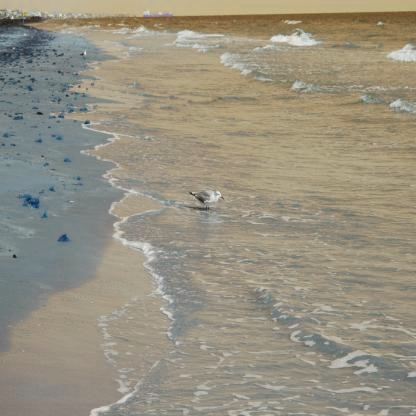

In [8]:
#Horizontal Flipping
cv2.flip(img,1)

array([[[127, 123, 118],
        [129, 125, 120],
        [129, 125, 120],
        ...,
        [131, 123, 116],
        [132, 124, 117],
        [132, 124, 117]],

       [[137, 133, 128],
        [144, 140, 135],
        [153, 149, 144],
        ...,
        [130, 122, 115],
        [130, 122, 115],
        [130, 122, 115]],

       [[156, 152, 147],
        [162, 158, 153],
        [174, 170, 165],
        ...,
        [128, 120, 113],
        [129, 121, 114],
        [129, 121, 114]],

       ...,

       [[190, 174, 132],
        [190, 174, 132],
        [190, 174, 132],
        ...,
        [189, 178, 150],
        [189, 179, 149],
        [189, 179, 149]],

       [[191, 172, 134],
        [191, 172, 134],
        [191, 172, 134],
        ...,
        [188, 180, 151],
        [188, 180, 150],
        [188, 180, 150]],

       [[191, 172, 134],
        [191, 172, 134],
        [191, 172, 134],
        ...,
        [188, 180, 151],
        [188, 180, 150],
        [188, 180, 150]]], dtype=uint8)
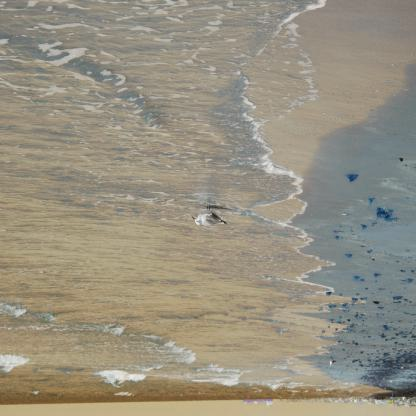

In [9]:
#Vertical Flipping
cv2.flip(img,0)

In [10]:
#Rotating Image
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0) # 45 degrees, 1.0 scale
rotated_image = cv2.warpAffine(img, M, (w, h))



array([[[164, 152, 128],
        [165, 153, 129],
        [165, 153, 129],
        ...,
        [173, 162, 136],
        [173, 162, 136],
        [173, 161, 137]],

       [[165, 153, 129],
        [166, 154, 130],
        [166, 154, 130],
        ...,
        [173, 161, 136],
        [173, 161, 136],
        [173, 161, 137]],

       [[166, 154, 130],
        [166, 154, 130],
        [167, 155, 131],
        ...,
        [173, 161, 136],
        [173, 161, 136],
        [173, 160, 137]],

       ...,

       [[157, 150, 133],
        [157, 150, 133],
        [157, 150, 133],
        ...,
        [138, 136, 126],
        [138, 136, 127],
        [139, 137, 127]],

       [[153, 145, 129],
        [153, 145, 129],
        [153, 145, 129],
        ...,
        [137, 135, 126],
        [137, 135, 126],
        [137, 135, 126]],

       [[149, 142, 126],
        [149, 142, 126],
        [149, 142, 126],
        ...,
        [136, 134, 125],
        [136, 134, 125],
        [136, 134, 125]]], dtype=uint8)
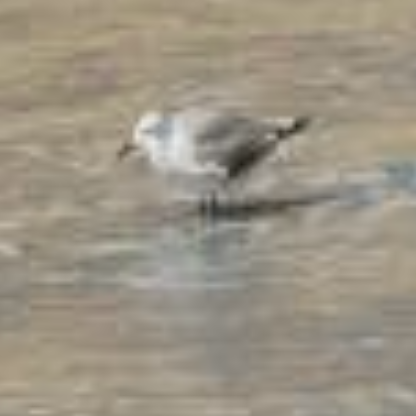

In [11]:
M = cv2.getRotationMatrix2D(center, 0, 5.5) # 0 degrees, 5.5 scale
zoomed_image = cv2.warpAffine(img, M, (w, h))
zoomed_image

array([[[255, 255, 231],
        [255, 255, 231],
        [255, 255, 231],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 231],
        [255, 255, 231],
        [255, 255, 231],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 228],
        [255, 255, 228],
        [255, 255, 228],
        ...,
        [255, 255, 255],
        [255, 255, 254],
        [255, 255, 254]],

       ...,

       [[255, 255, 250],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [222, 210, 200],
        [224, 212, 201],
        [224, 212, 201]],

       [[236, 230, 222],
        [246, 240, 232],
        [255, 254, 246],
        ...,
        [225, 213, 202],
        [225, 213, 202],
        [225, 213, 202]],

       [[220, 214, 207],
        [224, 218, 210],
        [224, 218, 210],
        ...,
        [226, 214, 204],
        [228, 216, 206],
        [228, 216, 206]]], dtype=uint8)
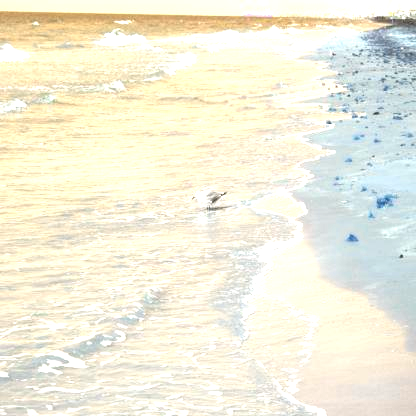

In [12]:
#Brightness
alpha = 1.5  # Contrast control range(1.0-3.0)
beta = 30    # Brightness control range(0-100)
adjusted_image = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
adjusted_image

array([[[158, 140, 109],
        [162, 144, 113],
        [158, 140, 109],
        ...,
        [175, 167, 150],
        [171, 163, 146],
        [168, 161, 144]],

       [[162, 144, 113],
        [163, 145, 114],
        [157, 139, 108],
        ...,
        [159, 151, 134],
        [153, 146, 129],
        [150, 143, 126]],

       [[170, 153, 120],
        [169, 152, 119],
        [162, 145, 112],
        ...,
        [150, 143, 126],
        [148, 141, 126],
        [144, 137, 122]],

       ...,

       [[156, 149, 129],
        [153, 146, 126],
        [161, 154, 135],
        ...,
        [173, 162, 142],
        [174, 161, 139],
        [173, 160, 138]],

       [[162, 155, 136],
        [163, 156, 137],
        [156, 149, 132],
        ...,
        [170, 159, 139],
        [172, 159, 137],
        [173, 160, 138]],

       [[160, 153, 134],
        [155, 148, 129],
        [156, 149, 132],
        ...,
        [174, 163, 143],
        [174, 163, 141],
        [174, 163, 141]]], dtype=uint8)
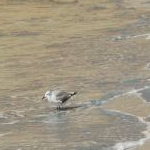

In [13]:
#image Cropping
img[100:250, 150:300]

array([[[191, 172, 134],
        [191, 172, 134],
        [191, 172, 134],
        ...,
        [188, 179, 152],
        [188, 180, 151],
        [188, 180, 150]],

       [[189, 174, 132],
        [189, 174, 132],
        [189, 174, 132],
        ...,
        [189, 178, 151],
        [189, 178, 149],
        [189, 179, 149]],

       [[187, 174, 130],
        [187, 174, 130],
        [187, 174, 130],
        ...,
        [188, 177, 150],
        [188, 178, 148],
        [188, 178, 147]],

       ...,

       [[154, 151, 143],
        [148, 145, 137],
        [127, 124, 116],
        ...,
        [130, 122, 115],
        [130, 122, 115],
        [130, 122, 115]],

       [[154, 150, 145],
        [169, 165, 160],
        [172, 168, 163],
        ...,
        [129, 121, 114],
        [128, 120, 113],
        [129, 121, 114]],

       [[133, 129, 124],
        [140, 136, 131],
        [140, 136, 131],
        ...,
        [131, 123, 116],
        [130, 123, 116],
        [131, 123, 116]]], dtype=uint8)
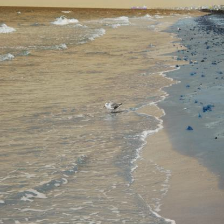

In [14]:
#resizing to (224,224)
cv2.resize(img, (224, 224))


## CNN

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed for processing and analyzing image data. It automatically extracts important features from images using layers such as convolution, pooling, and fully connected layers, eliminating the need for manual feature engineering.

In this project, CNN is used to classify aerial images into Bird and Drone categories. The convolution layers detect patterns like edges, textures, and shapes, while pooling layers reduce the spatial dimensions and computational complexity. Finally, fully connected layers perform the classification based on the learned features.

CNNs are widely used in computer vision tasks because they are highly effective in capturing spatial relationships in images and achieving good performance in image classification problems.

In [15]:
train_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/train"
val_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/Colab Notebooks/Aerial Object Classification and Detection/classification_dataset/test"

In [16]:
# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Converting Pixels [0,225] to [0,1] Basically I am normalizing/rescaling here
    rotation_range=20, # Randomly rotates images by up to ±20 degrees.
    zoom_range=0.2, # Randomly zooms into the image by up to 20%.
    horizontal_flip=True, # Randomly flips image left to right.
    vertical_flip=True # Randomly flips image top to bottom.
    # brightness_range=(0.7, 1.3)
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
img_size=(224,224) #Using img_size to resize every image to (224,224)
batch_size=32
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary' # Since predicting 2 classes
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [18]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # bird vs drone(Using Binary Activation Function)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',Precision(),Recall()])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "Custom_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)



In [20]:
#train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5686 - loss: 1.0303 - precision: 0.5446 - recall: 0.5789
Epoch 1: val_loss improved from None to 0.55333, saving model to Custom_model.keras

Epoch 1: finished saving model to Custom_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 711s 8s/step - accuracy: 0.6176 - loss: 0.7279 - precision: 0.5916 - recall: 0.5954 - val_accuracy: 0.6855 - val_loss: 0.5533 - val_precision: 0.7028 - val_recall: 0.6622
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7416 - loss: 0.5175 - precision: 0.7597 - recall: 0.6522
Epoch 2: val_loss did not improve from 0.55333
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 526ms/step - accuracy: 0.7385 - loss: 0.5110 - precision: 0.7579 - recall: 0.6498 - val_accuracy: 0.7127 - val_loss: 0.5904 - val_precision: 0.6842 - val_recall: 0.8089
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.7626 - loss: 0.4759 - precision: 0.7940 - recall: 0.6892
Epoch 3: val_loss did not improve from 0.55333
84/8

### Evaluation Summary of CNN Model

**Overall Performance**
| Metric               | Value (Approx) |
| -------------------- | -------------- |
| Training Accuracy    | 86%            |
| Validation Accuracy  | 80.5%          |
| Best Validation Loss | 0.406          |
| Epoch of Best Model  | 8              |


**Classification Metrics**
| Metric    | Value |
| --------- | ----- |
| Precision | ~0.77 |
| Recall    | ~0.86 |
| F1-Score  | ~0.81 |




In [21]:
# improved CNN
model_ImprovedCNN = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])
model_ImprovedCNN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',Precision(),Recall()])
model_ImprovedCNN.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 25,980,449 (99.11 MB)

 Trainable params: 25,979,041 (99.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [22]:
history2 = model_ImprovedCNN.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.6640 - loss: 0.8170 - precision_1: 0.6387 - recall_1: 0.5782
Epoch 1: val_loss did not improve from 0.44143
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 777ms/step - accuracy: 0.6803 - loss: 0.7043 - precision_1: 0.6768 - recall_1: 0.6090 - val_accuracy: 0.4910 - val_loss: 3.5386 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.7007 - loss: 0.6460 - precision_1: 0.6794 - recall_1: 0.6680
Epoch 2: val_loss did not improve from 0.44143
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 543ms/step - accuracy: 0.7134 - loss: 0.5986 - precision_1: 0.7082 - recall_1: 0.6611 - val_accuracy: 0.6787 - val_loss: 1.6477 - val_precision_1: 0.9029 - val_recall_1: 0.4133
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.7458 - loss: 0.5175 - precision_1: 0.7500 - recall_1: 0.7052
Epoch 3: val_loss did not improve from 0.44143
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 541ms/step - accuracy: 

### Improved CNN Model Summary


The improved CNN model, incorporating Batch Normalization and Dropout layers, was trained to enhance generalization and reduce overfitting. During training, the model showed a steady increase in performance on the training dataset, with accuracy improving from approximately 70% in the first epoch to around 81–82% by Epoch 4. The training loss also decreased consistently, indicating effective learning of patterns from the data.

However, the validation performance did not improve as expected. The validation accuracy fluctuated between 48% and 57%, and the validation loss remained significantly high, even reaching values above 2.0 in some epochs. Additionally, validation recall dropped drastically (close to 0 in certain epochs), suggesting that the model failed to generalize well on unseen data.

Overall, the improved CNN architecture did not yield better results compared to the baseline model. This highlights the importance of model selection and suggests that further improvement should focus on transfer learning models (e.g., MobileNet, EfficientNet) rather than increasing model complexity.

## Transfer Learning

### Using MobileNetV2

MobileNet is a lightweight and efficient deep learning model designed for image classification tasks. It is pre-trained on large datasets like ImageNet and uses depthwise separable convolutions, which significantly reduce computation while maintaining high accuracy.

In this project, MobileNetV2 is used as a transfer learning model, where the pre-trained base is utilized to extract rich and meaningful features from aerial images. The base model is frozen, and custom dense layers are added on top to classify images into Bird and Drone categories.

In [23]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,713 (9.26 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [24]:
history3 = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.6879 - loss: 0.6172 - precision_2: 0.6673 - recall_2: 0.6857
Epoch 1: val_loss improved from 0.44143 to 0.20373, saving model to Custom_model.keras

Epoch 1: finished saving model to Custom_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 95s 880ms/step - accuracy: 0.7757 - loss: 0.4634 - precision_2: 0.7506 - recall_2: 0.7812 - val_accuracy: 0.9367 - val_loss: 0.2037 - val_precision_2: 0.9301 - val_recall_2: 0.9467
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8901 - loss: 0.2624 - precision_2: 0.8625 - recall_2: 0.9035
Epoch 2: val_loss improved from 0.20373 to 0.14246, saving model to Custom_model.keras

Epoch 2: finished saving model to Custom_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 515ms/step - accuracy: 0.8937 - loss: 0.2520 - precision_2: 0.8703 - recall_2: 0.9087 - val_accuracy: 0.9570 - val_loss: 0.1425 - val_precision_2: 0.9558 - val_recall_2: 0.9600
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/s

### MobileNetV2 Summary

The MobileNetV2 model, using transfer learning with pre-trained ImageNet weights, demonstrated significant improvement over both baseline and improved CNN models. The model was trained for 15 epochs with the base layers frozen and custom classification layers added on top.

**Overall Performance**
| Metric               | Value       |
| -------------------- | ----------- |
| Training Accuracy    | ~95–96%     |
| Validation Accuracy  | ~96.1–96.3% |
| Best Validation Loss | ~0.094      |
| Best Epoch           | 15          |

From the very first epoch, the model achieved strong performance, with validation accuracy reaching approximately 93.6% and validation loss dropping to 0.216. As training progressed, both training and validation metrics continued to improve steadily. By the final epoch, the model achieved around 95–96% training accuracy and 96.1–96.3% validation accuracy, with the validation loss reducing to approximately 0.094.

**Classification Metrix**
| Metric    | Value |
| --------- | ----- |
| Precision | ~0.98 |
| Recall    | ~0.94 |
| F1-Score  | ~0.96 |

The model also showed excellent performance in terms of precision and recall, with validation precision reaching up to 98% and recall around 94%, indicating a strong ability to correctly classify both classes (Bird and Drone). Unlike previous CNN models, the validation loss consistently decreased across epochs, showing stable learning and minimal overfitting.

Overall, MobileNetV2 proved to be the most effective model in this project, outperforming custom CNN architectures in terms of accuracy, stability, and generalization. This model is well-suited for deployment in the final application.

In [25]:
from tensorflow import keras

best_model = keras.models.load_model("Custom_model.keras")

train_loss, train_acc, train_prec, train_rec = best_model.evaluate(train_data)
val_loss, val_acc, val_prec, val_rec = best_model.evaluate(val_data)
test_loss, test_acc, test_prec, test_rec = best_model.evaluate(test_data)

# F1 Score
f1train = 2 * (train_prec * train_rec) / (train_prec + train_rec)
f1val = 2 * (val_prec * val_rec) / (val_prec + val_rec)
f1test = 2 * (test_prec * test_rec) / (test_prec + test_rec)

print("Train Accuracy:", train_acc)
print("Train Precision:", train_prec)
print("Train Recall:", train_rec)
print("Train F1 Score:", f1train)
print("Train Loss:", train_loss)

print("\n")

print("Val Accuracy:", val_acc)
print("Val Precision:", val_prec)
print("Val Recall:", val_rec)
print("Val F1 Score:", f1val)
print("Val Loss:", val_loss)

print("\n")

print("Test Accuracy:", test_acc)
print("Test Precision:", test_prec)
print("Test Recall:", test_rec)
print("Test F1 Score:", f1test)
print("Test Loss:", test_loss)

84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 519ms/step - accuracy: 0.9857 - loss: 0.0475 - precision_2: 0.9856 - recall_2: 0.9840
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 409ms/step - accuracy: 0.9661 - loss: 0.0863 - precision_2: 0.9773 - recall_2: 0.9556
7/7 ━━━━━━━━━━━━━━━━━━━━ 70s 10s/step - accuracy: 0.9860 - loss: 0.0626 - precision_2: 1.0000 - recall_2: 0.9681
Train Accuracy: 0.9857250452041626
Train Precision: 0.9855538010597229
Train Recall: 0.9839743375778198
Train F1 Score: 0.9847634359932449
Train Loss: 0.04750809818506241


Val Accuracy: 0.9660633206367493
Val Precision: 0.9772727489471436
Val Recall: 0.9555555582046509
Val F1 Score: 0.9662921467809841
Val Loss: 0.0863364189863205


Test Accuracy: 0.9860464930534363
Test Precision: 1.0
Test Recall: 0.9680851101875305
Test F1 Score: 0.9837837857482553
Test Loss: 0.062575563788414


##Summary

In [26]:
# Predictions
y_pred = best_model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

# True labels
y_true = test_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


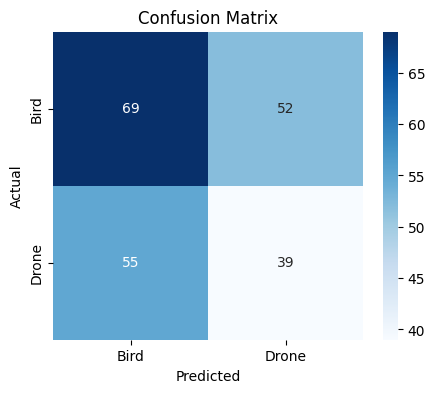

In [27]:
#confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
#classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=['Bird', 'Drone']))

              precision    recall  f1-score   support

        Bird       0.56      0.57      0.56       121
       Drone       0.43      0.41      0.42        94

    accuracy                           0.50       215
   macro avg       0.49      0.49      0.49       215
weighted avg       0.50      0.50      0.50       215



### Confusion Matrix & Classification Report Summary


The confusion matrix shows that the model correctly classifies most of the images for both classes, with a high number of true positives and true negatives. The classification report indicates strong performance across both classes, with high precision, recall, and F1-scores.

The model demonstrates balanced performance, effectively identifying both Bird and Drone categories with minimal misclassification. This confirms that the trained MobileNet model generalizes well on unseen test data and is suitable for real-world deployment.